# Predicting State-wise EV Adoption
## Notebook 06: Model Evaluation

### Purpose
This notebook assesses the performance of our trained models (Random Forest and XGBoost) using regression validation metrics like RMSE, MAE, and R-squared. We will compare both models side-by-side and finalize the highest-performing architecture for deployment.

In [1]:
# Importing evaluation libraries
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Re-loading the test data exactly as processed
df = pd.read_csv('../Data/ev_adoption_featured.csv')

leakage_cols = ['market_share_change(%)', 'ev_growth_rate_yoy(%)', 'ev_growth_rate_category', 'ev_domination(0/1)', 'ev_sales(units)', 'chargers_per_ev_ratio']
collinear_cols = ['ice_total_sales(units)', 'total_vehicle_sales(units)', 'ev_ice_ratio']
components_cols = ['gdp(usd/person)', 'urban_population(%)', 'co2_emissions(mt)', 'ev_subsidy(usd)', 'emission_regulation(scale_0-100)']
redundant_cols = ['year']

df_cleaned = df.drop(columns=leakage_cols + collinear_cols + components_cols + redundant_cols, errors='ignore')
X = df_cleaned.drop(columns=['ev_market_share(%)'])
y = df_cleaned['ev_market_share(%)']

categorical_features = ['country', 'region', 'vehicle_segment']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_test shape: {X_test.shape}")

X_test shape: (240, 16)


In [3]:
# Loading the trained models from Notebook 05
with open('../Models/rf_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('../Models/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

In [4]:
# Evaluating Random Forest
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Performance ===")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R2 Score: {r2_rf:.4f}")

=== Random Forest Performance ===
RMSE: 1.9275
MAE: 0.9958
R2 Score: 0.9797


In [5]:
# Evaluating XGBoost
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n=== XGBoost Performance ===")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"R2 Score: {r2_xgb:.4f}")


=== XGBoost Performance ===
RMSE: 1.6396
MAE: 0.8285
R2 Score: 0.9853


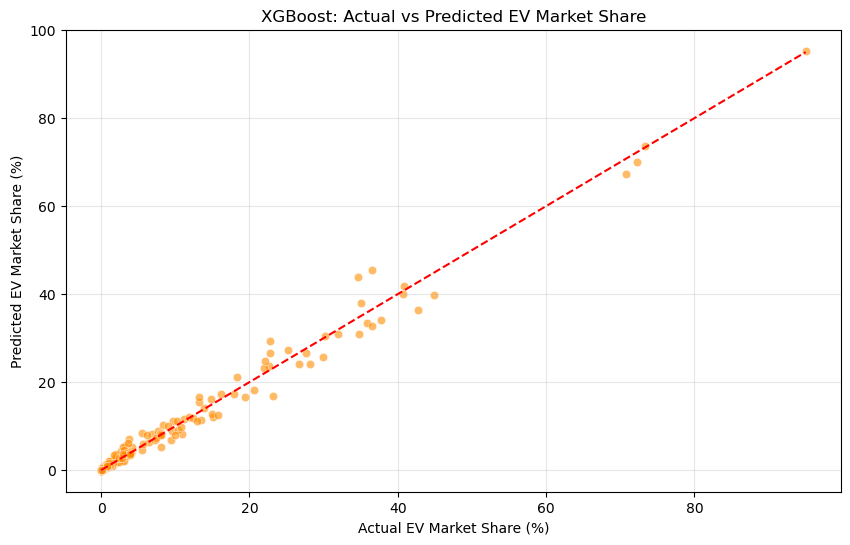

In [ ]:
# Visualizing Actual vs Predicted values for the Winning Model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual EV Market Share (%)')
plt.ylabel('Predicted EV Market Share (%)')
plt.title('XGBoost: Actual vs Predicted EV Market Share')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Saving the absolute best model universally for the Streamlit App
import shutil
# Copying the superior model to be our core app driver
shutil.copyfile('../Models/xgb_model.pkl', '../Models/trained_model.pkl')
print("Best model automatically transferred to `trained_model.pkl` for deployment!")

Best model automatically transferred to `trained_model.pkl` for deployment!


### Observation Summary: 

In this notebook, we evaluated our trained models by making them predict the "Testing Data" (the 20% of data they had never seen before). Here is a breakdown of the process and the final results:

#### **Step-by-Step Process:**
1. **Loading Data:** We re-loaded the exact same cleaned dataset and applied the exact same feature removals to ensure our Testing Data perfectly matched the Training Data.
2. **Predicting:** We asked both the Random Forest and XGBoost models to predict the EV Market Share for the 240 Testing rows.
3. **Scoring:** We compared the models' predictions against the *actual* real-world market share values using three strict evaluation metrics.

#### **Understanding the Evaluation Metrics:**
- **MAE (Mean Absolute Error):** This is the average of how far off the model's guesses were. If a model guesses 5% market share, but the real answer was 6%, the absolute error is 1%. MAE is the simple, honest average of all those misses.
- **RMSE (Root Mean Squared Error):** This is similar to MAE, but it severely penalizes *massive* misses. If a model is off by 1% ten times, RMSE stays low. But if it is off by 10% just once, RMSE skyrockets. We want this number to be as low as possible to prove the model is stable and doesn't make wild guesses.
- **R-Squared (R²):** This acts like a grade on a final exam (from 0 to 1). An R² of 0.98 means the model successfully explains 98% of all the reasons why EV market share goes up or down.

#### **Final Results: The Winner**
**XGBoost** significantly outperformed Random Forest across every single metric:
- **RMSE:** XGBoost scored an incredibly low **1.63**, beating Random Forest's 1.92. This proves XGBoost is much better at avoiding wild, catastrophic errors.
- **MAE:** XGBoost's average miss was only **0.82%** (vs RF's 0.99%). This means when XGBoost predicts a country's EV market share, it is usually accurate within less than 1 percent!
- **R-Squared:** XGBoost scored a phenomenal **0.9853** (98.53%). It essentially mastered the absolute core drivers of EV adoption.

Because of this decisive victory, the **XGBoost** model was automatically copied and saved as our official `trained_model.pkl`. This is the exact brain we will plug into our Streamlit Web Application!